In [36]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.io.img_tiles as cimgt

import cmcrameri.cm as cmc

from geoscripts.dz import dz,mda

In [4]:
path = 'laserchron_data/VanTongeren_MR24_compiled geochron.xlsx'
sheets = ['MR24-10','MR24-12','MR24-13','MR24-15','MR24-16']

In [9]:
data = []
for sheet in sheets:
    accepted = pd.read_excel(path,skiprows=22,header=None,index_col=0,usecols='A:T',
                             sheet_name=sheet)
    
    cols_combined = accepted.iloc[0] + ' ' + accepted.iloc[1]
    accepted.columns = cols_combined
    accepted.drop(accepted.index[:3],inplace=True)

    accepted = accepted[accepted.index.str.contains(sheet)]
    name = sheet[:5] + sheet[5:].zfill(3)
    print(name)

    data.append((accepted,name))

MR24-010
MR24-012
MR24-013
MR24-015
MR24-016


In [11]:
# Get location data from field notes
meta_mr = pd.read_csv('field_data/2024_mr_field_samples.csv',index_col=0)
locations = meta_mr[['Latitude','Longitude']]

No 3 ages overlap at 2 sigma. Defaulting to 3 youngest ages
3 grains at 2 sigma did not succeed. Trying 2 grains at 1 sigma
No 2 ages overlap at 1 sigma. Defaulting to 2 youngest ages


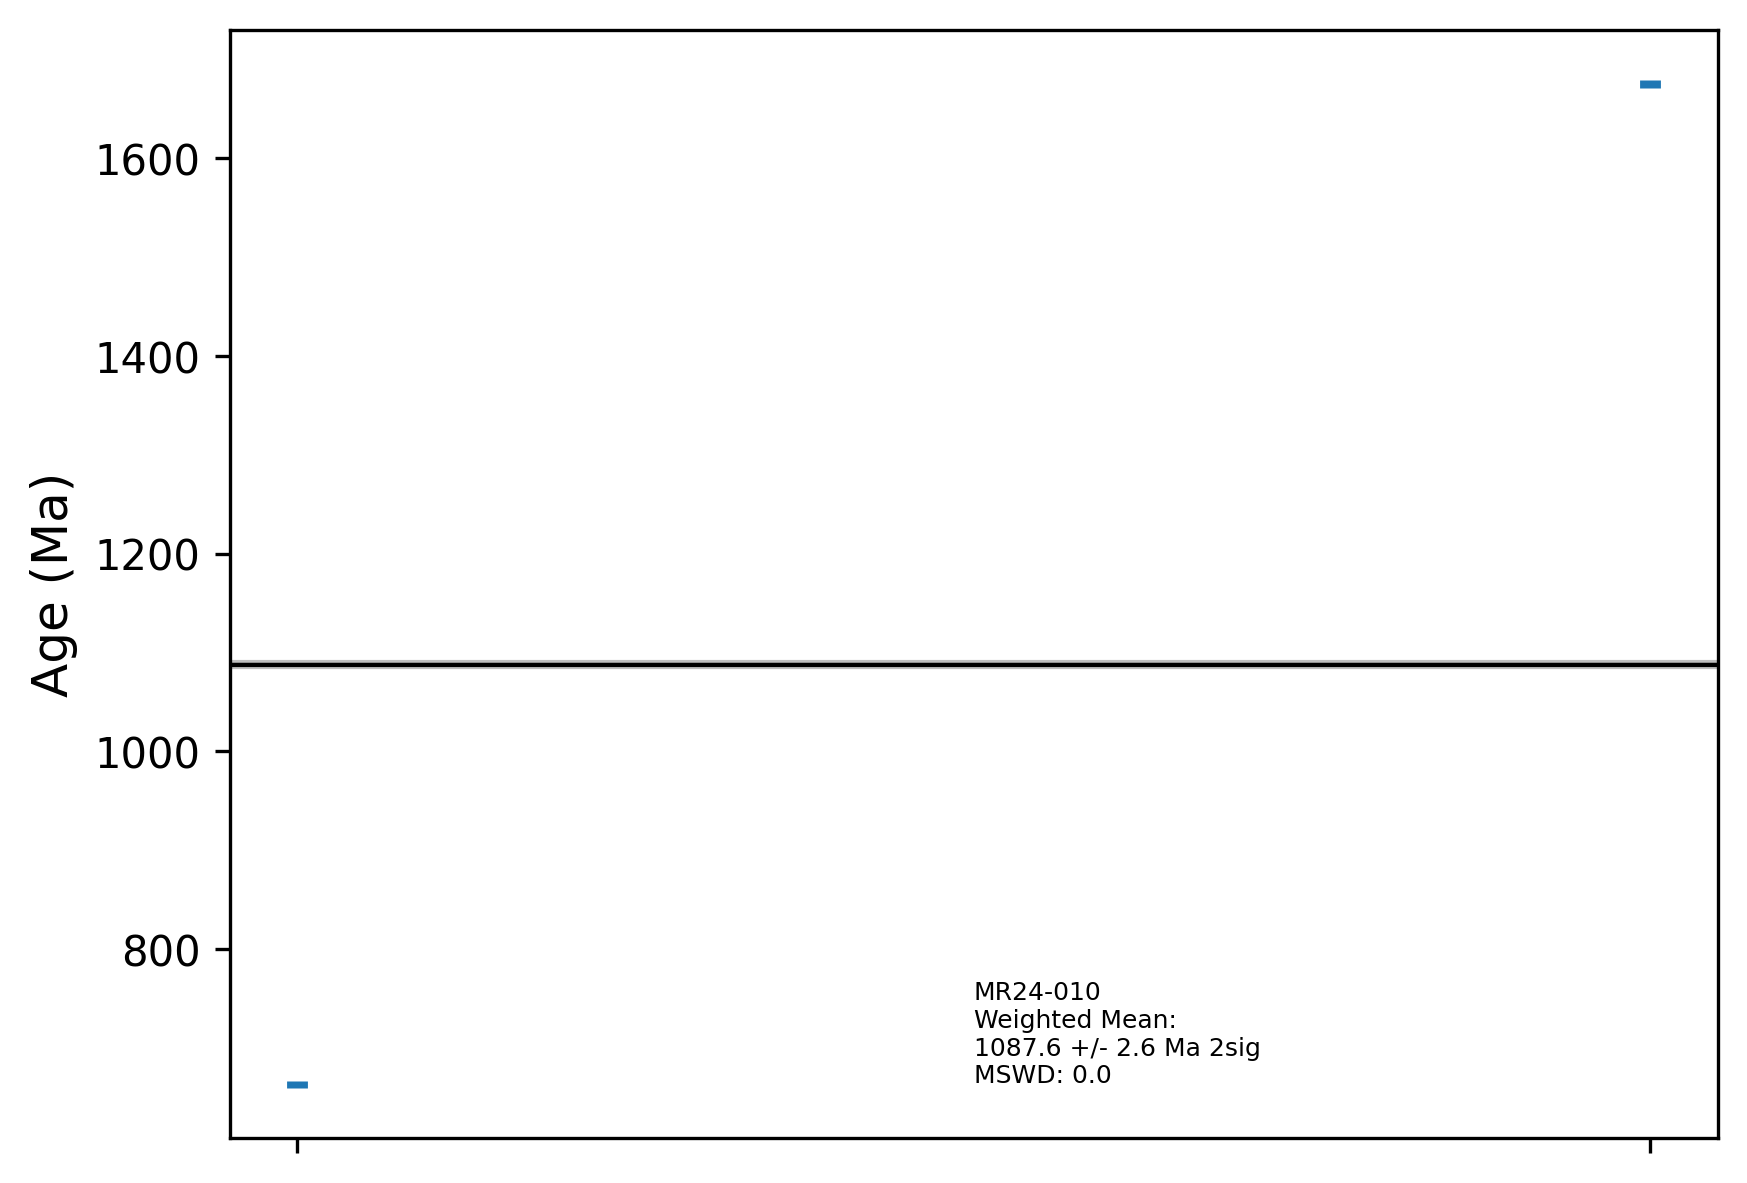

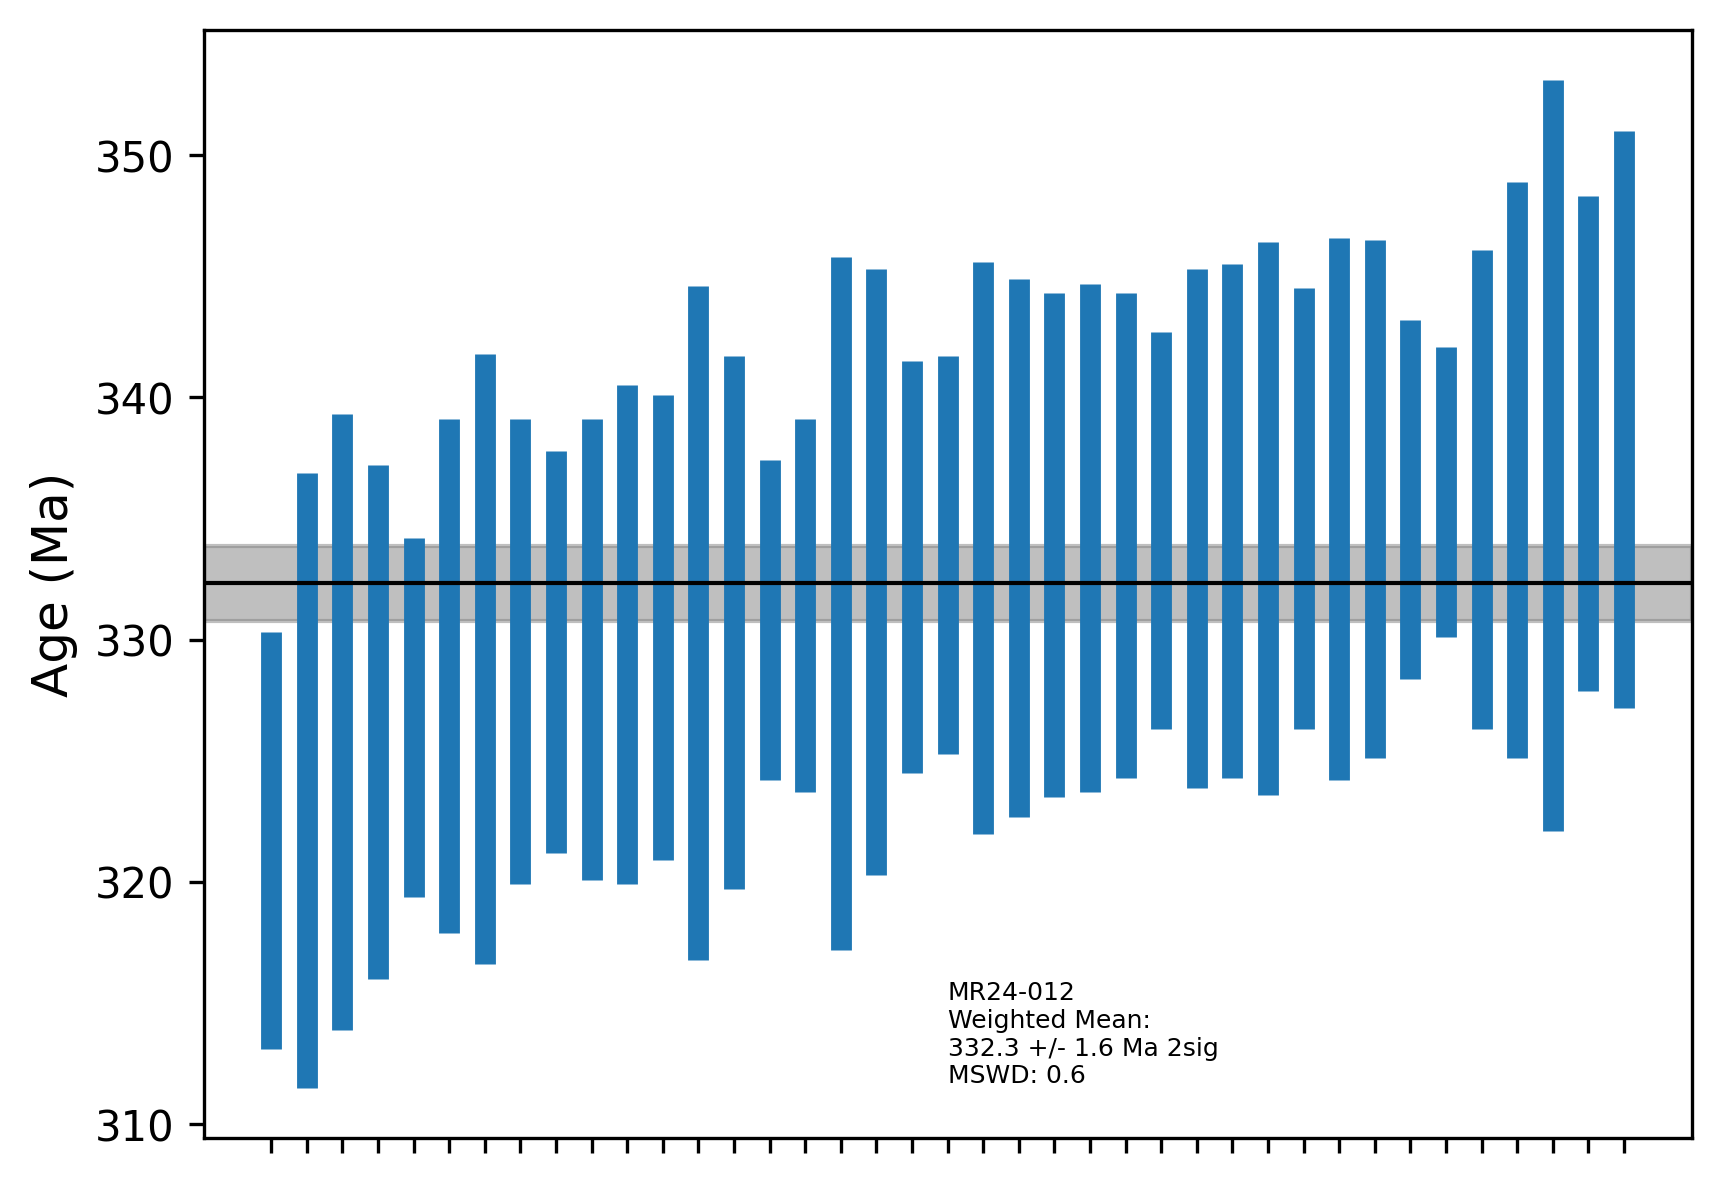

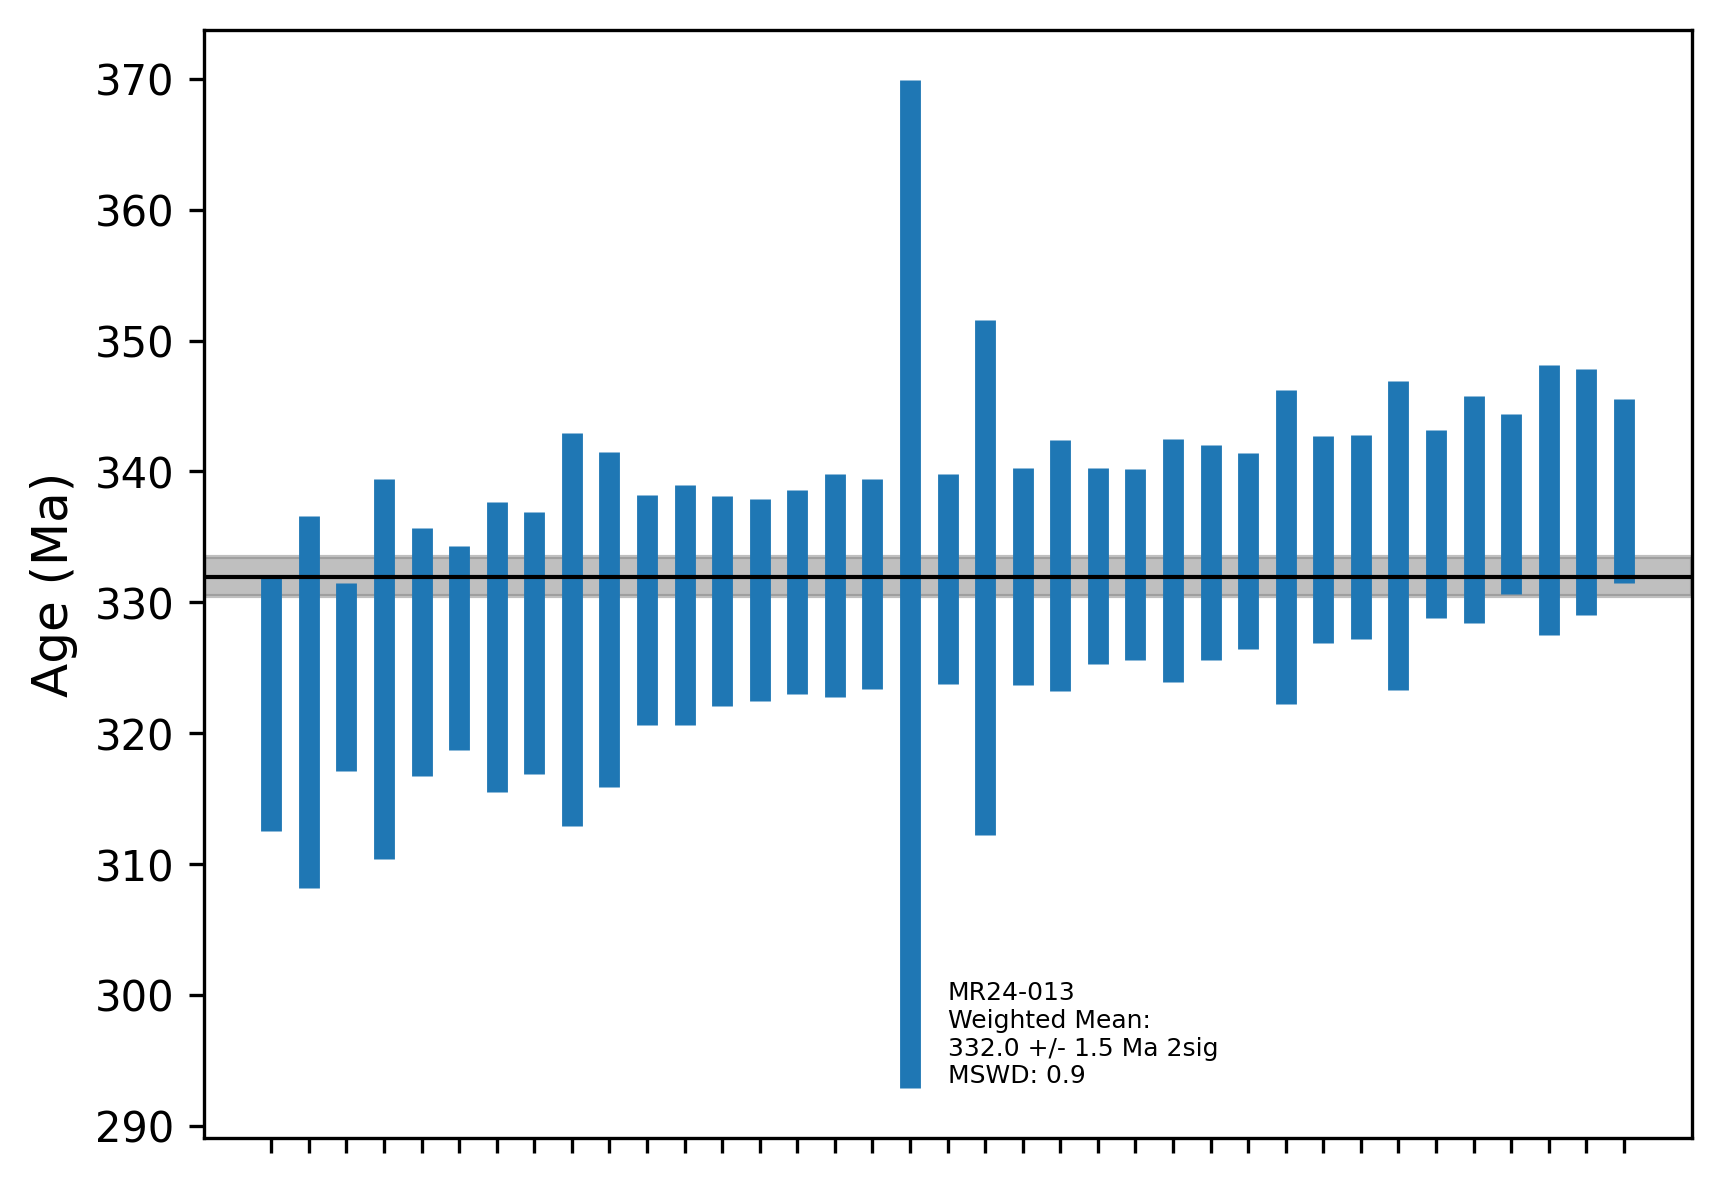

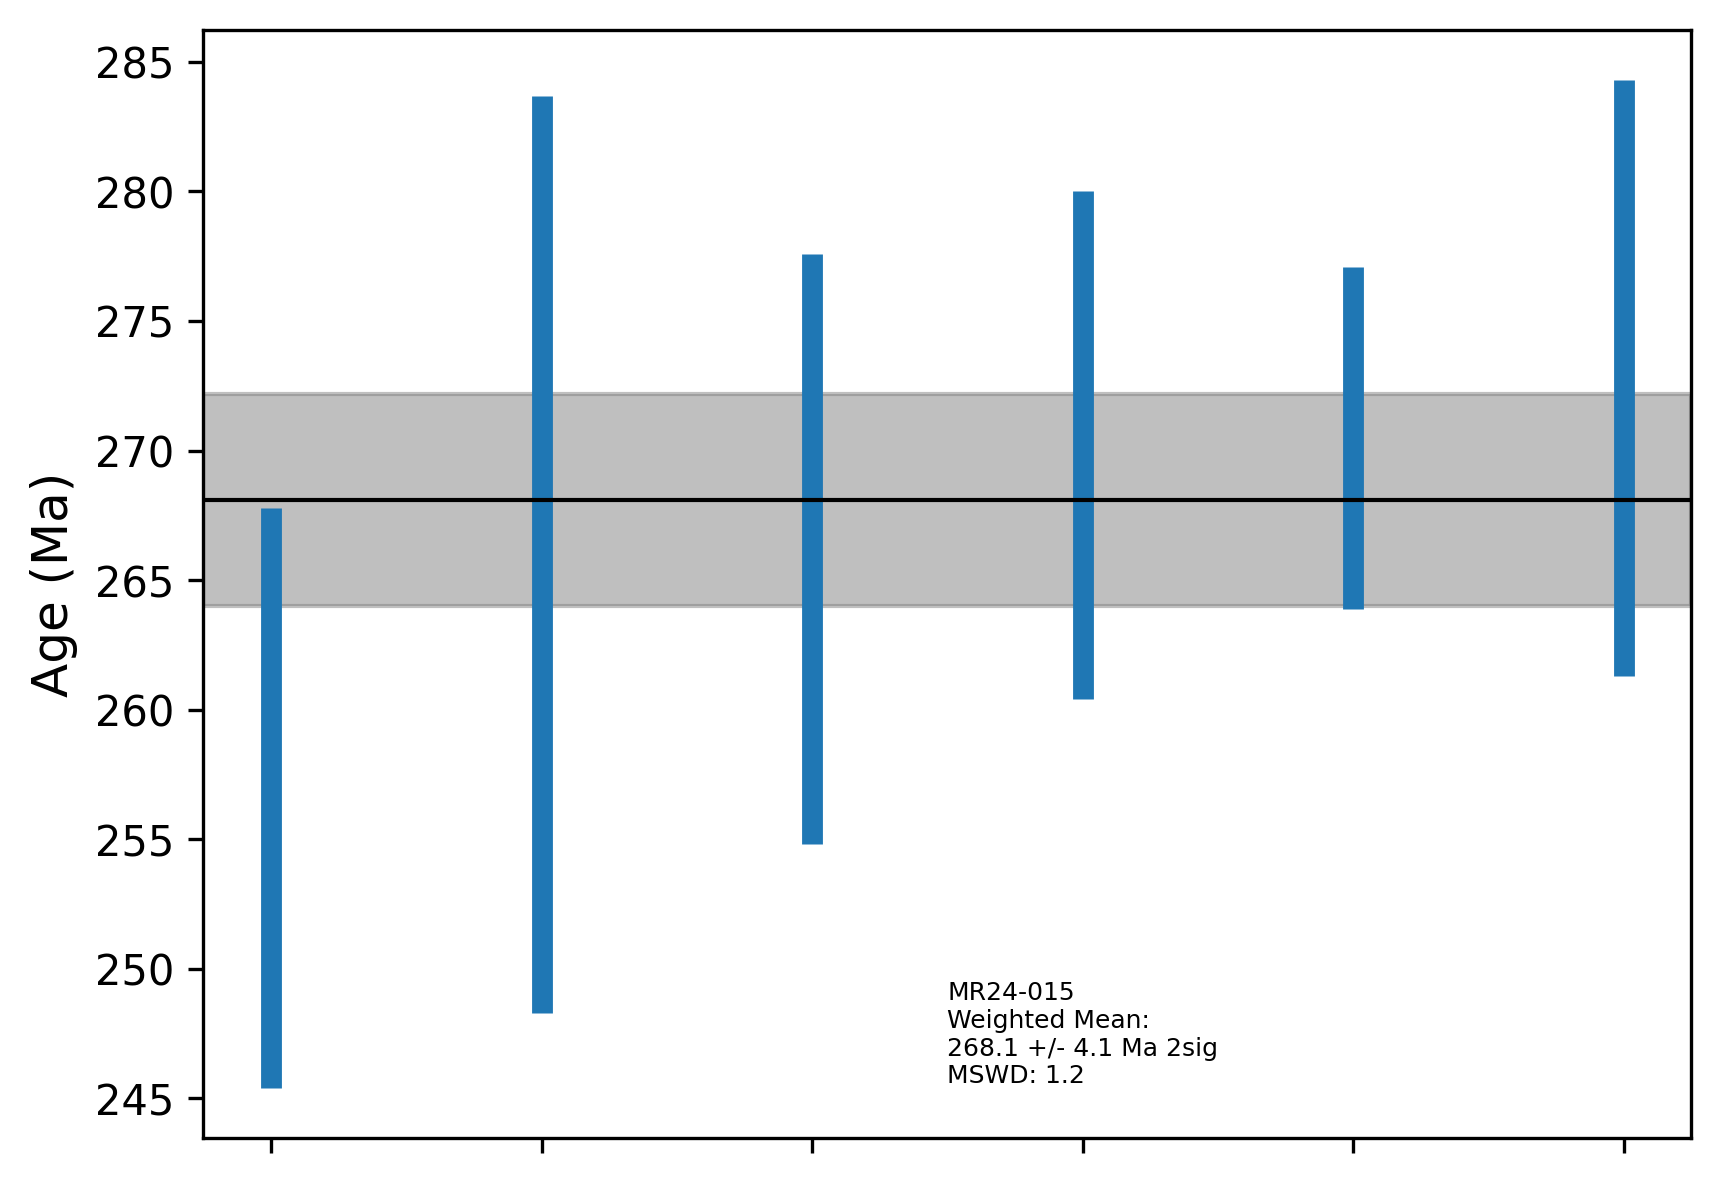

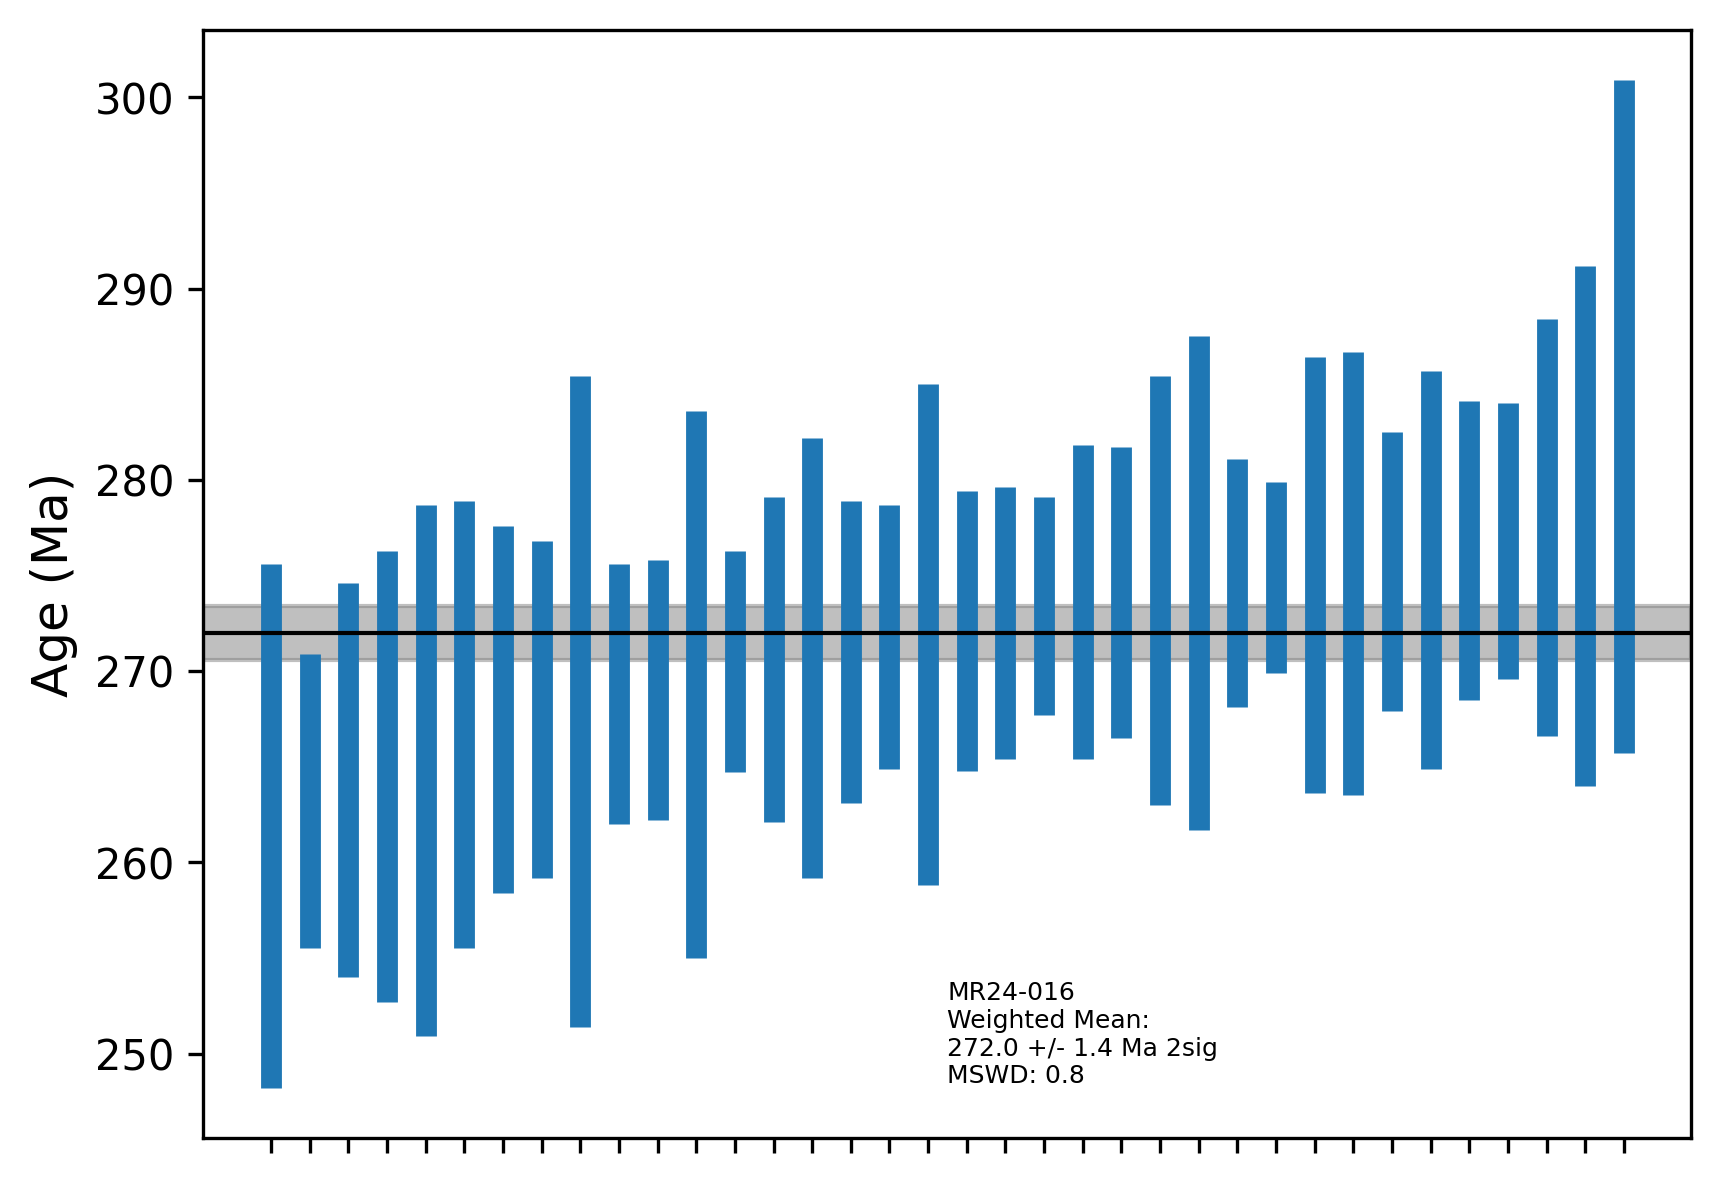

In [43]:
# Create DZ objects from data
smps = [dz.DZSample(name=sample[1],agedata=sample[0],
                    latlon=(locations.loc[sample[1],'Latitude'],
                            locations.loc[sample[1],'Longitude']),
                            source='VanTongeren',reported_age='P-Tr') for sample in data]
smps.sort(key=lambda x: x.name)

for smp in smps:
    smp.bestage = smp.agedata['Best age (Ma)'].astype(float)
    smp.bestage.name = 'Best Age'
    smp.besterror = smp.agedata.iloc[:,-2].astype(float)
    smp.besterror.name = '2sig'
    smp.error_level = '2sig'
    smp.calc_mda()

    smp.save()

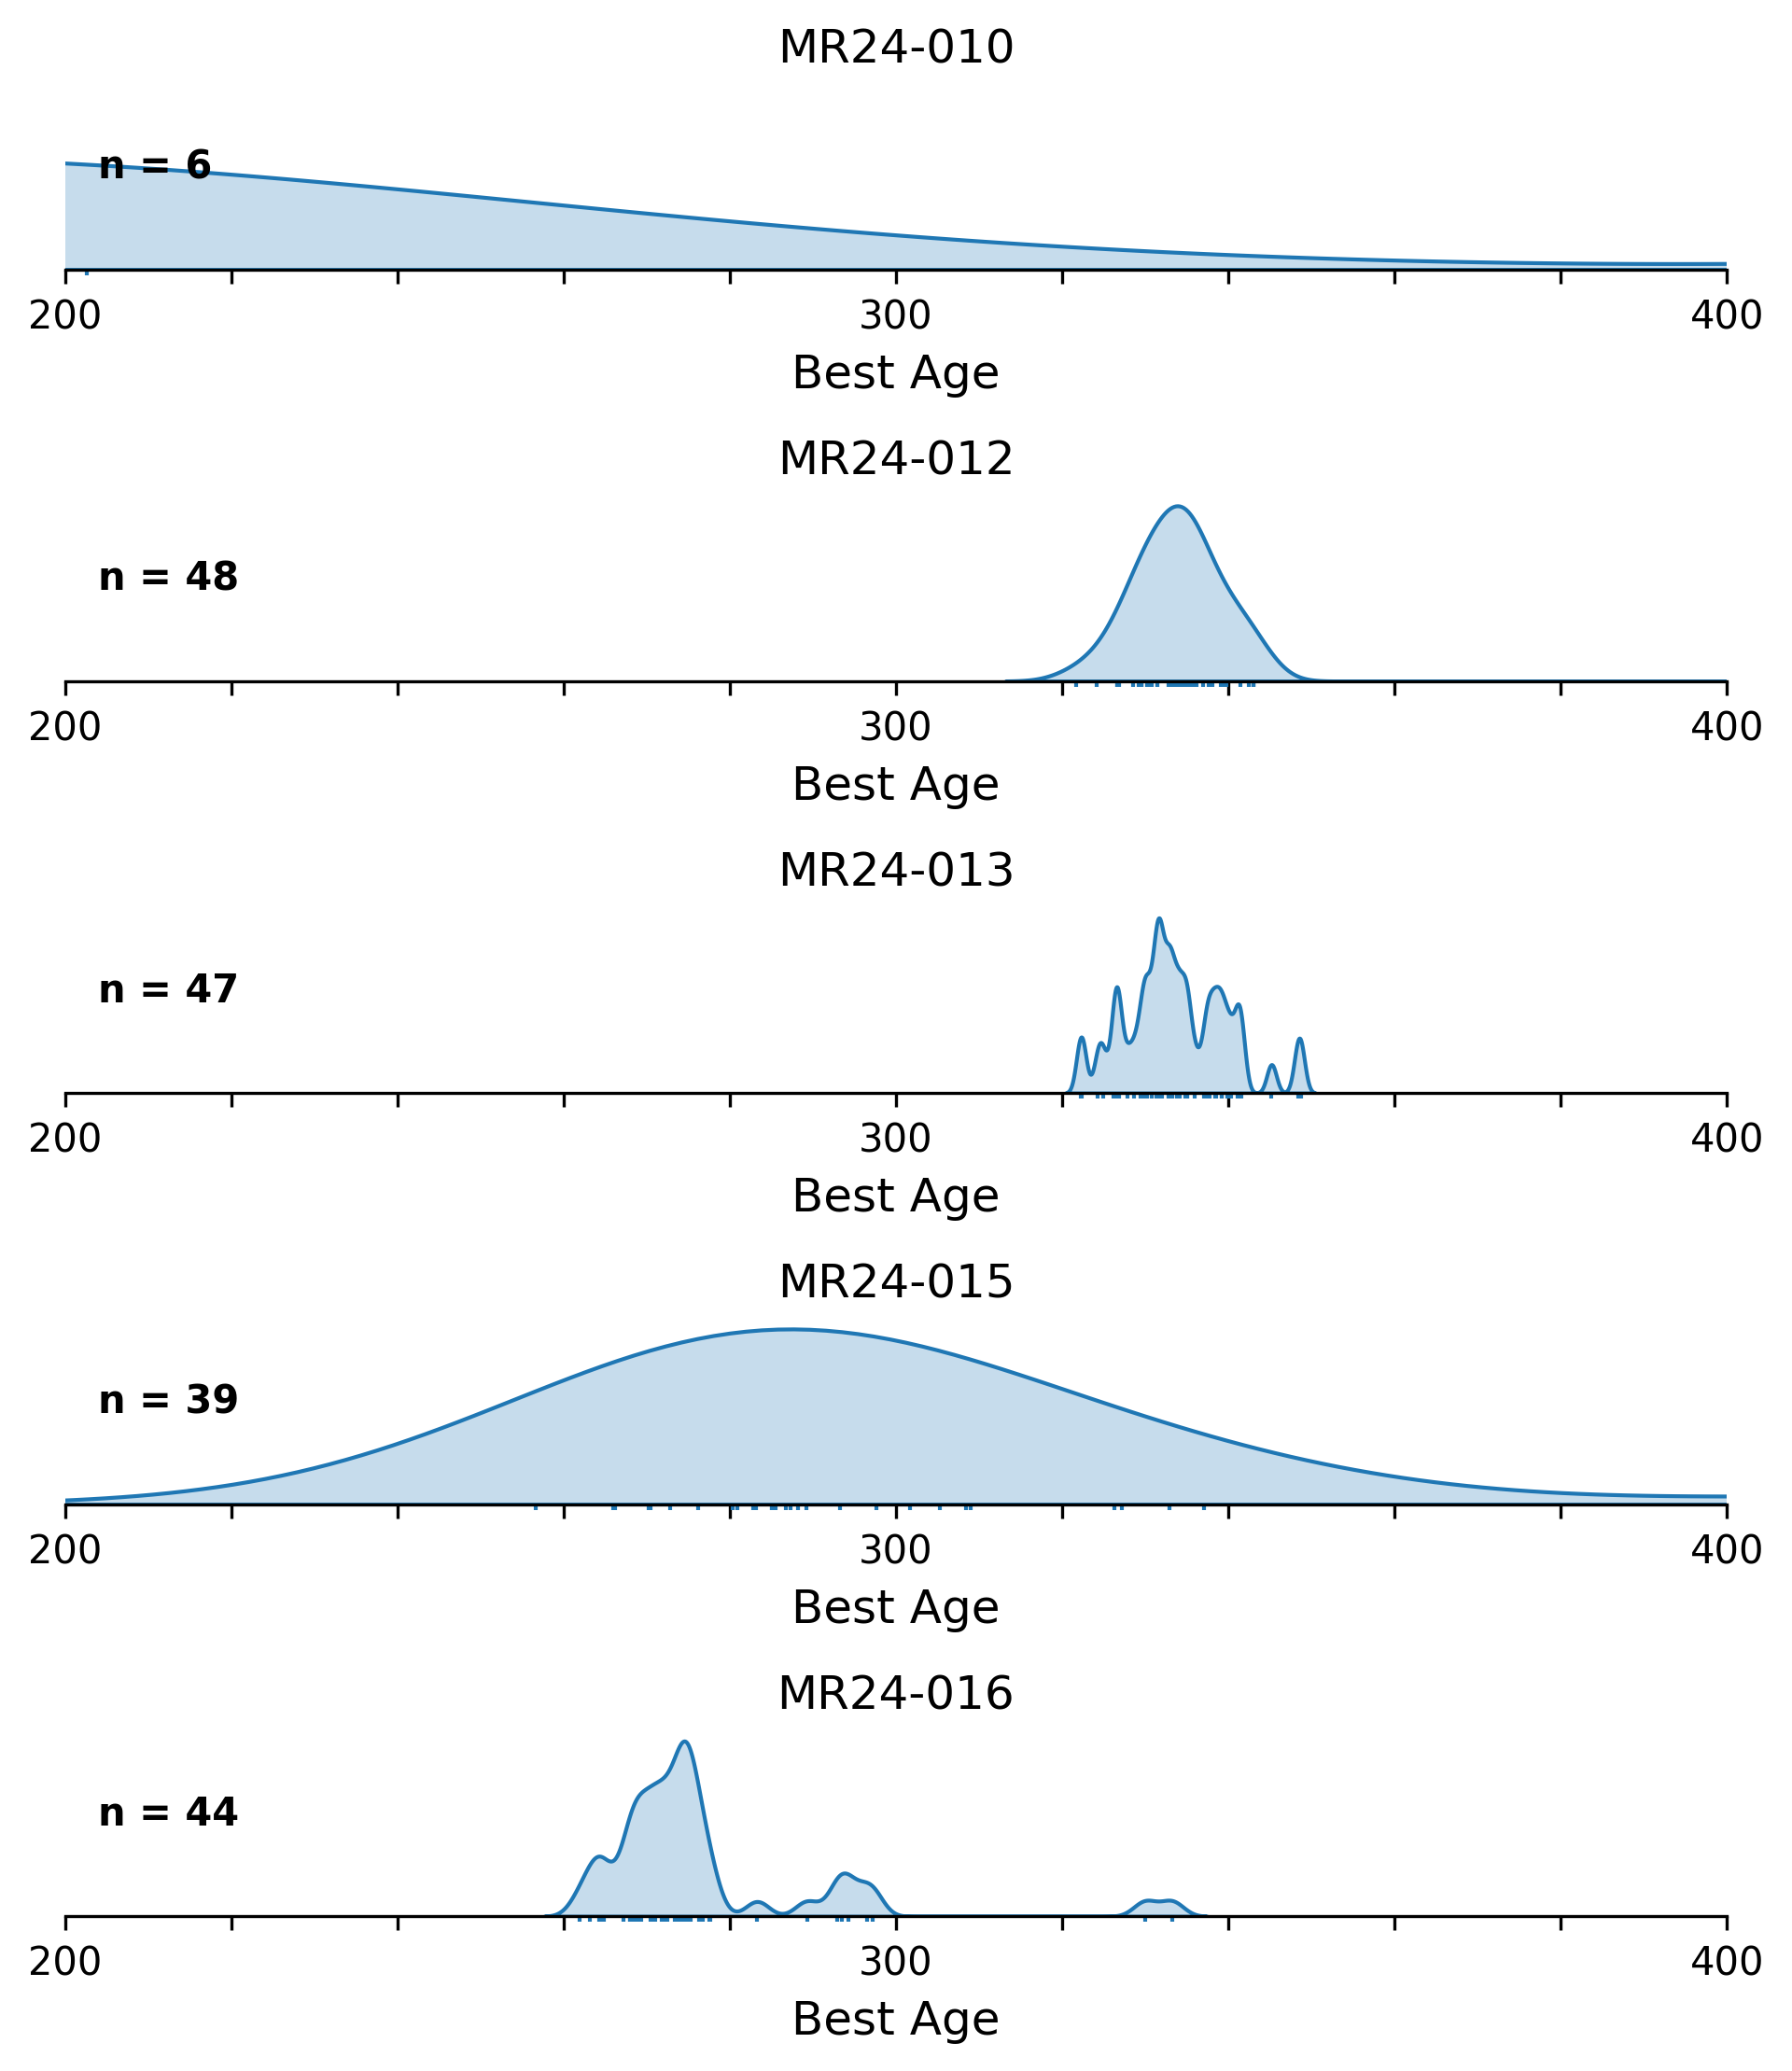

In [45]:
# Plot KDEs using existing best ages (not calculated)
fig,axs = plt.subplots(len(smps),figsize=(6.5,1.5*len(smps)),dpi=300)

for k,smp in enumerate(smps):
    ax = axs[k]
    smp.kde(ax=ax,bw_adjust=0.2,log_scale=False)
    ax.set_xlim(200,400)
    ax.set_title(smp.name)
    ax.set_xticks(np.arange(200,401,20))

plt.tight_layout()
fig.savefig('kdes_ig.pdf')

In [ ]:
# Calculate weighted mean ages (no sysetmatic error, yet)
